In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import gc,os
print(gc.collect(),"\n",os.getcwd())

16 
 /content


In [ ]:
%pip install autogluon

In [ ]:
# Cleaned and fixed notebook (copy-paste run)
import pandas as pd
import numpy as np
import polars as pl
import gc
import sys
import subprocess

# ===========================
# INSTALLATION & IMPORT
# ===========================
# AutoGluon (silent install)
subprocess.check_call([sys.executable, "-m", "pip", "install", "autogluon.tabular", "-q"])
from autogluon.tabular import TabularPredictor

# ===========================
# CONFIGURATION
# ===========================
RANDOM_STATE = 42
SAMPLE_SIZE = 800_000  # taille échantillon réduite pour la mémoire
TIME_LIMIT = 1800      # time_limit en secondes (ici 1800 = 30 minutes)

print("🎯 CONFIGURATION POUR MAXIMISER ROC AUC")
print(f"📊 Taille échantillon: {SAMPLE_SIZE}")
print(f"⏰ Time limit (s): {TIME_LIMIT}")

# ===========================
# PHASE 1: CHARGEMENT DONNÉES POLARS
# ===========================
print("\n🔄 CHARGEMENT DES DONNÉES...")

train_lazy = pl.scan_parquet("/content/drive/MyDrive/train_interactions.parquet")
items_meta = pl.read_parquet("/content/drive/MyDrive/items_meta.parquet")
users_meta = pl.read_parquet("/content/drive/MyDrive/users_meta.parquet")

try:
    test_pairs = pl.read_parquet("/content/drive/MyDrive/test_pairs_public.parquet")
    print("✅ test_pairs chargé avec Polars")
except Exception as e:
    print("⚠️  Chargement Polars échoué, conversion depuis Pandas...", e)
    test_pairs_pd = pd.read_parquet("/content/drive/MyDrive/test_pairs_public.parquet")
    test_pairs = pl.from_pandas(test_pairs_pd)

train_data = train_lazy.collect()
print("📊 DIMENSIONS INITIALES:")
print(f"  Train: {train_data.shape}")
print(f"  Items: {items_meta.shape}")
print(f"  Users: {users_meta.shape}")
print(f"  Test:  {test_pairs.shape}")

🎯 CONFIGURATION POUR MAXIMISER ROC AUC
📊 Taille échantillon: 800000
⏰ Time limit (s): 1800

🔄 CHARGEMENT DES DONNÉES...
✅ test_pairs chargé avec Polars
📊 DIMENSIONS INITIALES:
  Train: (122360517, 7)
  Items: (337727, 4)
  Users: (183404, 3)
  Test:  (3572662, 2)


In [ ]:
# ===========================
# PHASE 2: PRÉTRAITEMENT & ÉCHANTILLONNAGE
# ===========================
print("\n🎯 PRÉTRAITEMENT ET ÉCHANTILLONNAGE...")

# Filtrage interactions utiles
train_data = train_data.filter(
    (pl.col("int1") + pl.col("int2") + pl.col("int3") + pl.col("int4")) >= 1
)
print(f"✅ Train filtré: {train_data.shape}")

# Échantillonnage équilibré
pos_count = train_data.filter(pl.col("int1") == 1).height
neg_count = train_data.filter(pl.col("int1") == 0).height
print(f"📊 Distribution: Positifs={pos_count}, Négatifs={neg_count}")

actual_sample_size = min(SAMPLE_SIZE, train_data.height)
n_each = actual_sample_size // 2

neg_sample = train_data.filter(pl.col("int1") == 0).sample(n=n_each)
pos_sample = train_data.filter(pl.col("int1") == 1).sample(
    n=n_each,
    with_replacement=(pos_count < n_each)
)

train_balanced = pl.concat([neg_sample, pos_sample]).sample(fraction=1.0, shuffle=True, seed=RANDOM_STATE)
print(f"✅ Train équilibré: {train_balanced.shape}")


🎯 PRÉTRAITEMENT ET ÉCHANTILLONNAGE...
✅ Train filtré: (6652264, 7)
📊 Distribution: Positifs=5662422, Négatifs=989842
✅ Train équilibré: (800000, 7)


In [ ]:
# ===========================
# PHASE 3: FUSION METADATA
# ===========================
print("\n🔗 FUSION AVEC METADATA...")

train_enriched = (
    train_balanced
    .join(users_meta, on="uid", how="left")
    .join(items_meta, on="iid", how="left")
)
test_enriched = (
    test_pairs
    .join(users_meta, on="uid", how="left")
    .join(items_meta, on="iid", how="left")
)
print(f"📈 Train enrichi: {train_enriched.shape}")
print(f"📊 Test enrichi: {test_enriched.shape}")


🔗 FUSION AVEC METADATA...
📈 Train enrichi: (800000, 12)
📊 Test enrichi: (3572662, 7)


In [ ]:
# ===========================
# PHASE 4: FEATURE ENGINEERING (SAFE)
# ===========================
def apply_core_features(df_input: pl.DataFrame, is_train_data: bool = True) -> pl.DataFrame:

    df = df_input.clone()

    # If test and ts missing, add ts with zeros (UInt8)
    if not is_train_data and "ts" not in df.columns:
        df = df.with_columns(pl.lit(0).cast(pl.UInt8).alias("ts"))

    # Ensure int2/int3/int4 exist in test (train already has them)
    if not is_train_data:
        missing_ints = []
        for c in ["int2", "int3", "int4"]:
            if c not in df.columns:
                missing_ints.append(pl.lit(0).cast(pl.UInt8).alias(c))
        if missing_ints:
            df = df.with_columns(missing_ints)

    # Interaction scores (int1 must NOT be used)
    # safe: only int2,int3,int4 used
    df = df.with_columns([
        (pl.col("int3") * 2 - pl.col("int2") * 1.5 + pl.col("int4")).alias("weighted_interaction"),
        (pl.col("int3") - pl.col("int2") + pl.col("int4")).alias("interaction_score"),
        ((pl.col("int3") + 1) / (pl.col("int2") + pl.col("int4") + 1)).alias("pos_neg_ratio"),
        (pl.col("int3") > 0).cast(pl.Int8).alias("has_positive"),
        (pl.col("int2") > 0).cast(pl.Int8).alias("has_negative"),
        (pl.col("int4") > 0).cast(pl.Int8).alias("has_neutral")
    ])

    # TS features (ts will exist)
    df = df.with_columns([
        pl.col("ts").alias("ts_numeric"),
        pl.col("ts").cast(pl.Utf8).alias("ts_categorical"),
        pl.when(pl.col("ts") < 85).then(pl.lit("low"))
          .when(pl.col("ts") < 170).then(pl.lit("medium"))
          .otherwise(pl.lit("high"))
          .alias("ts_binned")
    ])
    # Replace original ts with numeric ts (keeps column name 'ts' numeric for AutoGluon)
    df = df.drop("ts").rename({"ts_numeric": "ts"})

    # Embeddings: replace nulls with zero vector and explode
    if "emb" in df.columns:
        # gather a non-null embedding to infer length
        emb_series = df.select("emb").to_series().drop_nulls()
        emb_len = 32  # default
        if len(emb_series) > 0 and emb_series[0] is not None:
            try:
                emb_len = len(emb_series[0])
            except Exception:
                emb_len = 32
        df = df.with_columns(
            pl.when(pl.col("emb").is_null())
              .then(pl.lit([0.0] * emb_len))
              .otherwise(pl.col("emb"))
              .alias("emb")
        )
        emb_exprs = [pl.col("emb").list.get(i).alias(f"emb_{i}") for i in range(emb_len)]
        df = df.with_columns(emb_exprs).drop("emb")

    # Default columns (hour, dayofweek)
    df = df.with_columns([pl.lit(0).alias("hour"), pl.lit(0).alias("dayofweek")])

    # Fill nulls
    df = df.fill_null(0)

    return df

# Apply to train to compute user/item stats
train_features_intermediate = apply_core_features(train_enriched, is_train_data=True)

# Compute user and item stats (from training data only)
user_stats = train_features_intermediate.group_by("uid").agg([
    pl.col("weighted_interaction").mean().alias("user_avg_interaction"),
    pl.col("has_positive").mean().alias("user_positive_rate"),
    pl.count("uid").alias("user_total_interactions"),
    pl.col("weighted_interaction").std().fill_null(0).alias("user_interaction_std")
])

item_stats = train_features_intermediate.group_by("iid").agg([
    pl.col("weighted_interaction").mean().alias("item_avg_interaction"),
    pl.col("has_positive").mean().alias("item_positive_rate"),
    pl.count("iid").alias("item_popularity"),
    pl.col("weighted_interaction").std().fill_null(0).alias("item_interaction_std")
])

# Join stats back (LEFT joins keep all rows)
train_features = train_features_intermediate.join(user_stats, on="uid", how="left")
train_features = train_features.join(item_stats, on="iid", how="left")
train_features = train_features.fill_null(0)

print(f"📈 Train features: {train_features.shape}")

# Apply to test and join the stats from training set
test_features_intermediate = apply_core_features(test_enriched, is_train_data=False)
test_features = test_features_intermediate.join(user_stats, on="uid", how="left")
test_features = test_features.join(item_stats, on="iid", how="left")
test_features = test_features.fill_null(0)

print(f"📊 Test features: {test_features.shape}")

📈 Train features: (800000, 61)
📊 Test features: (3572662, 60)


In [ ]:
# ===========================
# PHASE 5: CONVERSION PANDAS & REDUCTION MEMOIRE
# ===========================
df_train = train_features.to_pandas()
df_test = test_features.to_pandas()

def reduce_memory_advanced(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        col_type = df[col].dtype
        if str(col_type).startswith("int64"):
            c_min, c_max = df[col].min(), df[col].max()
            if c_min >= 0:
                if c_max <= 255: df[col] = df[col].astype('uint8')
                elif c_max <= 65535: df[col] = df[col].astype('uint16')
                elif c_max <= 4294967295: df[col] = df[col].astype('uint32')
            else:
                if c_min >= -128 and c_max <= 127: df[col] = df[col].astype('int8')
                elif c_min >= -32768 and c_max <= 32767: df[col] = df[col].astype('int16')
                elif c_min >= -2147483648 and c_max <= 2147483647: df[col] = df[col].astype('int32')
        elif str(col_type).startswith("float64"):
            df[col] = df[col].astype('float32')
        elif col_type == object:
            if df[col].nunique() / max(1, len(df)) < 0.5:
                df[col] = df[col].astype('category')
    return df

df_train = reduce_memory_advanced(df_train)
df_test = reduce_memory_advanced(df_test)
gc.collect()

print(f"\n🎯 DONNÉES FINALES POUR AUTOGLUON: Train {df_train.shape}, Test {df_test.shape}")
print(f"🔢 Target distribution:\n{df_train['int1'].value_counts()}")


🎯 DONNÉES FINALES POUR AUTOGLUON: Train (800000, 61), Test (3572662, 60)
🔢 Target distribution:
int1
0    400000
1    400000
Name: count, dtype: int64


In [ ]:
# ===========================
# PHASE 6: PRÉPARATION POUR AUTOGLUON (corrigé)
# ===========================
target = "int1"

# Variables pour AutoGluon si besoin
X_train_ag = df_train.drop(columns=[target])
y_train_ag = df_train[target].copy()
X_test_ag = df_test.copy()

# Assurer que 'ts' existe dans X_train_ag et X_test_ag (rarement absent)
required_cols = ["ts"]
for col in required_cols:
    if col not in X_train_ag.columns:
        X_train_ag[col] = df_train.get(col, 0)
    if col not in X_test_ag.columns:
        X_test_ag[col] = df_test.get(col, 0)

print("\n✅ Colonnes AutoGluon prêtes.")
print("🧩 X_train_ag:", X_train_ag.shape)
print("🎯 y_train_ag:", y_train_ag.shape)
print("🧪 X_test_ag:", X_test_ag.shape)


✅ Colonnes AutoGluon prêtes.
🧩 X_train_ag: (800000, 60)
🎯 y_train_ag: (800000,)
🧪 X_test_ag: (3572662, 60)


In [ ]:
# ===========================
# PHASE 7: AUTOGLUON
# ===========================
hyperparameters = {
    'GBM': [{'extra_trees': True}, {}, {'learning_rate': 0.05, 'num_leaves': 256, 'feature_fraction': 0.8, 'min_data_in_leaf': 20}],
    'CAT': [{'iterations': 1000, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 5}, {'iterations': 500, 'learning_rate': 0.02, 'depth': 10, 'l2_leaf_reg': 3}],
    'XGB': [{'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.8}, {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'subsample': 0.9}],
    'RF': [{'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 5}, {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10}]
}

# Fit using the full df_train (AutoGluon accepts dataframe with label)
predictor = TabularPredictor(
    label=target,
    problem_type="binary",
    eval_metric="roc_auc"
).fit(
    df_train,
    presets="best_quality",
    time_limit=TIME_LIMIT,
    num_stack_levels=1,  # réduit pour mémoire/temps
    num_bag_folds=3,
    hyperparameters=hyperparameters,
    verbosity=2
)

# Leaderboard and summary
leaderboard = predictor.leaderboard(df_train, silent=False)
best_model = leaderboard.iloc[0]["model"]
best_score = leaderboard.iloc[0]["score_val"]
print(f"\n🎯 MEILLEUR MODÈLE: {best_model}, ROC AUC (val) : {best_score:.6f}")
predictor.fit_summary()

No path specified. Models will be saved in: "AutogluonModels/ag-20251201_124237"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Memory Avail:       8.06 GB / 12.67 GB (63.6%)
Disk Space Avail:   62.38 GB / 107.72 GB (57.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=3, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets o

                 model  score_test  score_val eval_metric  pred_time_test  pred_time_val     fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0    LightGBM_3_BAG_L1    0.993718   0.986553     roc_auc       29.291847      13.396247   148.463731                29.291847               13.396247         148.463731            1       True          3
1    LightGBM_2_BAG_L2    0.992087   0.986742     roc_auc      218.736463     116.893983   967.214969                19.835825               14.656132         151.461428            2       True          6
2      LightGBM_BAG_L2    0.991831   0.986837     roc_auc      232.732683     119.695378  1014.714345                33.832045               17.457527         198.960804            2       True          5
3  WeightedEnsemble_L3    0.991584   0.986893     roc_auc      252.603248     134.518151  1197.978052                 0.034740                0.166641          31.802279           

{'model_types': {'LightGBM_BAG_L1': 'StackerEnsembleModel_LGB',
  'LightGBM_2_BAG_L1': 'StackerEnsembleModel_LGB',
  'LightGBM_3_BAG_L1': 'StackerEnsembleModel_LGB',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel',
  'LightGBM_BAG_L2': 'StackerEnsembleModel_LGB',
  'LightGBM_2_BAG_L2': 'StackerEnsembleModel_LGB',
  'LightGBM_3_BAG_L2': 'StackerEnsembleModel_LGB',
  'WeightedEnsemble_L3': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBM_BAG_L1': np.float64(0.9867482477281251),
  'LightGBM_2_BAG_L1': np.float64(0.9866012650062499),
  'LightGBM_3_BAG_L1': np.float64(0.9865533391374999),
  'WeightedEnsemble_L2': np.float64(0.9868577992875001),
  'LightGBM_BAG_L2': np.float64(0.98683654175625),
  'LightGBM_2_BAG_L2': np.float64(0.986741720465625),
  'LightGBM_3_BAG_L2': np.float64(0.9755863916906251),
  'WeightedEnsemble_L3': np.float64(0.9868926509625)},
 'model_best': 'WeightedEnsemble_L3',
 'model_paths': {'LightGBM_BAG_L1': ['LightGBM_BAG_L1'],
  'LightGBM_2_BAG_L1': ['LightG

In [ ]:
# ============================================
# 🔥 PERFORMANCES DURANT L'ENTRAÎNEMENT (résumé + graphique)
# ============================================

print("\n📊 === PERFORMANCES DURANT L’ENTRAÎNEMENT ===")
leaderboard_brief = predictor.leaderboard(silent=True)
best_model_row = leaderboard_brief.sort_values("score_val", ascending=False).head(1)
print(best_model_row)

best_model_name = best_model_row["model"].values[0]
print(f"\n🏆 Meilleur modèle sélectionné : {best_model_name}")


📊 === PERFORMANCES DURANT L’ENTRAÎNEMENT ===
                 model  score_val eval_metric  pred_time_val     fit_time  \
0  WeightedEnsemble_L3   0.986893     roc_auc     134.518151  1197.978052   

   pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  \
0                0.166641          31.802279            3       True   

   fit_order  
0          8  

🏆 Meilleur modèle sélectionné : WeightedEnsemble_L3


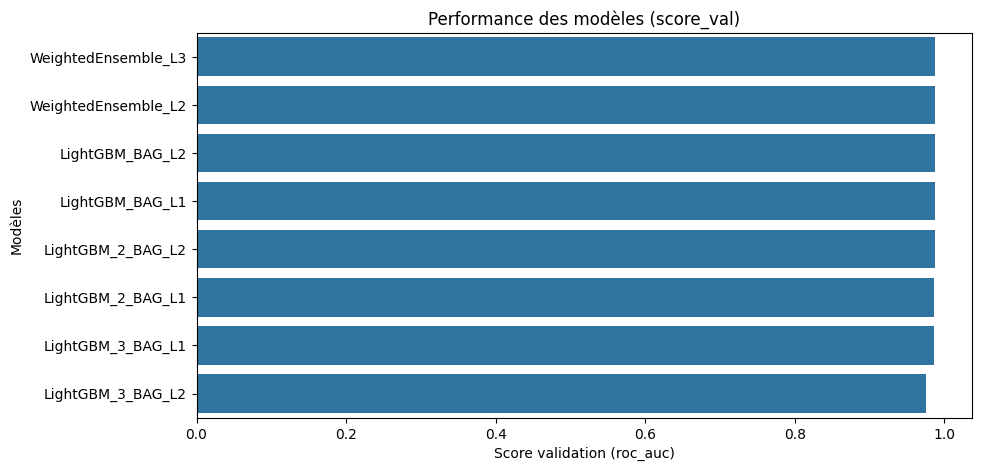

In [ ]:
# --- Graphique des performances des modèles ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    data=leaderboard_brief.sort_values("score_val", ascending=False),
    x="score_val",
    y="model"
)
plt.title("Performance des modèles (score_val)")
plt.xlabel("Score validation (roc_auc)")
plt.ylabel("Modèles")
plt.show()

In [ ]:
# ============================================
# 🔮 PREDICTIONS SUR LE TEST (probas + graphs)
# ============================================

print("\n🔮 PREDICTIONS SUR LE TEST (génération des probabilités)...")

# Probabilités classe positive
try:
    proba = predictor.predict_proba(df_test)[1]  # index 1 = proba classe positive
except Exception:
    proba = predictor.predict(df_test)  # fallback score

# ============================================
# 📂 CONSTRUCTION DE LA SUBMISSION
# ============================================

submission_df = pl.DataFrame({
    "uid": df_test["uid"].astype(str),
    "iid": df_test["iid"].astype(str),
    "target": proba
})

submission_df = submission_df.with_columns(
    pl.concat_str([pl.col("uid"), pl.lit("_"), pl.col("iid")]).alias("id")
).select(["id", "target"])

# Création du dossier si besoin
import os
os.makedirs("submissions", exist_ok=True)

submission_path = "submissions/submission_autogluon_Data_Tour_finale.parquet"
submission_df.write_parquet(submission_path)
print(f"✅ Submission saved to: {submission_path}")


🔮 PREDICTIONS SUR LE TEST (génération des probabilités)...
✅ Submission saved to: submissions/submission_autogluon_Data_Tour_finale.parquet


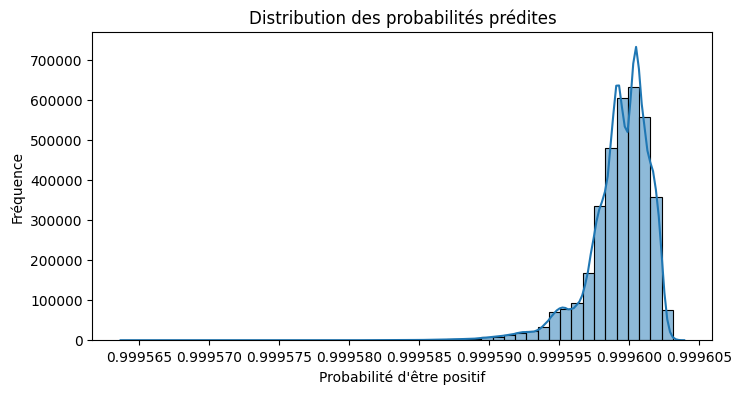

In [ ]:
# ============================================
# 📊 GRAPHIQUE 1 : DISTRIBUTION DES PROBABILITÉS
# ============================================

plt.figure(figsize=(8, 4))
sns.histplot(proba, bins=50, kde=True)
plt.title("Distribution des probabilités prédites")
plt.xlabel("Probabilité d'être positif")
plt.ylabel("Fréquence")
plt.show()

In [ ]:
# ============================================
# 📊 GRAPHIQUE 2 : IMPORTANCE DES FEATURES
# ============================================

try:
    importance_df = predictor.feature_importance(df_train)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df.sort_values("importance", ascending=False).head(25),
        x="importance",
        y="feature"
    )
    plt.title("Importance des variables (Top 25)")
    plt.show()
except:
    print("⚠️ Impossible de calculer l'importance des features pour ce modèle.")


These features in provided data are not utilized by the predictor and will be ignored: ['has_positive', 'has_negative', 'has_neutral', 'hour', 'dayofweek']
Computing feature importance via permutation shuffling for 55 features using 5000 rows with 5 shuffle sets...
	469.05s	= Expected runtime (93.81s per shuffle set)
	447.8s	= Actual runtime (Completed 5 of 5 shuffle sets)


⚠️ Impossible de calculer l'importance des features pour ce modèle.


<Figure size 1000x600 with 0 Axes>

In [ ]:
print("====================================")
print("📌 PERFORMANCES DU MODÈLE (VALIDATION)")
print("====================================")

# Résumé des performances internes
leaderboard = predictor.leaderboard(silent=True)
print(leaderboard)


📌 PERFORMANCES DU MODÈLE (VALIDATION)
                 model  score_val eval_metric  pred_time_val     fit_time  \
0  WeightedEnsemble_L3   0.986893     roc_auc     134.518151  1197.978052   
1  WeightedEnsemble_L2   0.986858     roc_auc     102.457833   831.715815   
2      LightGBM_BAG_L2   0.986837     roc_auc     119.695378  1014.714345   
3      LightGBM_BAG_L1   0.986748     roc_auc      70.736656   443.156056   
4    LightGBM_2_BAG_L2   0.986742     roc_auc     116.893983   967.214969   
5    LightGBM_2_BAG_L1   0.986601     roc_auc      18.104949   224.133754   
6    LightGBM_3_BAG_L1   0.986553     roc_auc      13.396247   148.463731   
7    LightGBM_3_BAG_L2   0.975586     roc_auc     103.505432   854.120342   

   pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  \
0                0.166641          31.802279            3       True   
1                0.219981          15.962274            2       True   
2               17.457527         198.960804        

In [ ]:
print("====================================")
print("📌 PERFORMANCE SUR LE TEST SET")
print("====================================")

y_pred = predictor.predict(df_test)
print("Aperçu des prédictions :", y_pred.head())

# Si test a des labels
try:
    test_score = predictor.evaluate_predictions(
        y_true=test_labels,
        y_pred=y_pred,
        auxiliary_metrics=True
    )
    print("Score sur test :", test_score)
except:
    print("⚠️ Aucun label dans test → évaluation impossible.")

📌 PERFORMANCE SUR LE TEST SET
Aperçu des prédictions : 0    1
1    1
2    1
3    1
4    1
Name: int1, dtype: uint8
⚠️ Aucun label dans test → évaluation impossible.


In [ ]:
import matplotlib.pyplot as plt

# Corrected: use df_train (Pandas DataFrame) for feature_importance
importance_df = predictor.feature_importance(df_train, y_train_ag)

plt.figure(figsize=(8, 10))
importance_df["importance"].head(20).plot(kind="barh")
plt.title("Top 20 features les plus importantes")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
plt.figure(figsize=(7,4))
# Corrected: use df_test (Pandas DataFrame) for predict_proba
y_pred_proba = predictor.predict_proba(df_test)[1]
plt.hist(y_pred_proba, bins=30)
plt.title("Distribution des probabilités prédites")
plt.xlabel("Probabilité d'être positif")
plt.ylabel("Nombre de cas")
plt.show()

In [ ]:
if 'label' in test_features.columns:
    plt.figure(figsize=(6,4))
    test_features['label'].value_counts().plot(kind="bar")
    plt.title("Répartition des classes dans le dataset")
    plt.xlabel("Classe")
    plt.ylabel("Nombre d'exemples")
    plt.show()
else:
    print("⚠️ Aucun label dans le test → impossible de faire le graphique des classes")


In [ ]:
!pip freeze > requirements.txt
